#### 00 - Dependencies

In [22]:
import os

os.environ["LLM_API_KEY"] = os.environ.get("LLM_API_KEY", "")
os.environ["LLM_BASE_URL"] = os.environ.get("LLM_BASE_URL", "https://openrouter.ai/api/v1")
os.environ["LLM_MODEL"] = os.environ.get("LLM_MODEL", "openai/gpt-4o-mini")
os.environ["LLM_TEMPERATURE"] = os.environ.get("LLM_TEMPERATURE", "0")

#### 1.0 - Data

- load
- split
- embed

In [23]:
from langchain_community.document_loaders import WebBaseLoader
import bs4

url = "https://claude.com/blog/millennium-and-anthropic-are-building-a-digital-risk-analyst-with-claude"
classes = ["u-rich-text-blog u-margin-trim w-richtext"]
loader = WebBaseLoader(
    web_paths=(url,),
    bs_kwargs=dict(parse_only=bs4.SoupStrainer(class_=tuple(classes))),
)
docs = loader.load()
print(len(docs), "documents loaded from the web page")

1 documents loaded from the web page


In [24]:
import langchain
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=0,
    length_function=len,
)
splits = text_splitter.split_documents(docs)
print(len(splits), "splits created from the documents")

4 splits created from the documents


In [25]:
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import Chroma

embeddings = OpenAIEmbeddings(
    api_key=os.environ.get("LLM_API_KEY", ""),
    base_url=os.environ.get("LLM_BASE_URL", "https://openrouter.ai/api/v1"),
)

vectorstore = Chroma.from_documents(documents=splits, 
                                    embedding=embeddings)
retriever = vectorstore.as_retriever(
    search_type="similarity_score_threshold",
    search_kwargs={"score_threshold": 0.8}
)


#### 2.0 - Retrieve and Generate

- prompt
- llm
- graph

In [26]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

prompt_template = """Answer the question based only on the following context:
{context}

Question: {question}
"""
prompt = ChatPromptTemplate.from_template(prompt_template)

llm = ChatOpenAI(
    model=os.environ.get("LLM_MODEL", "openai/gpt-4o-mini"),
    temperature=float(os.environ.get("LLM_TEMPERATURE", "0")),
    api_key=os.environ.get("LLM_API_KEY", ""),
    base_url=os.environ.get("LLM_BASE_URL", "https://openrouter.ai/api/v1"),
)

In [27]:
from typing import Literal
from pydantic import BaseModel, Field

class RouteQuery(BaseModel):
    """Route a user query to the most relevant handler."""

    datasource: Literal["vectorstore", "general"] = Field(
        ...,
        description=(
            "Use 'vectorstore' for questions about 'Millennium and Anthropic are building a digital risk analyst with Claude' and 'general' "
            "for anything else."
        ),
    )

router_prompt_template = """Decide whether the user is asking about this new topic of anthropics about 'Millennium and Anthropic are building a digital risk analyst with Claude' or not. 
Only return vectorstore if it is and general otherwise.
"""
router_prompt = ChatPromptTemplate.from_messages(
        [
            ("system", router_prompt_template),
            ("human", "{question}"),
        ]
    )

router_llm = llm.with_structured_output(RouteQuery)

In [28]:
graders_prompt_template = """No relative documents found for the given query. Review the query and rewrite it to be relevant to the topic of 'Millennium and Anthropic are building a digital risk analyst with Claude'."""
grader_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", graders_prompt_template),
        ("human", "{question}"),
    ]
)
grader_llm = ChatOpenAI(
    model=os.environ.get("LLM_MODEL", "openai/gpt-4o-mini"),
    temperature=float(os.environ.get("LLM_TEMPERATURE", "0")),
    api_key=os.environ.get("LLM_API_KEY", ""),
    base_url=os.environ.get("LLM_BASE_URL", "https://openrouter.ai/api/v1"),
)


In [34]:
class HallucinationCheck(BaseModel):
    """Check if the answer is hallucinated or not."""

    is_hallucinated: bool = Field(
        ...,
        description=(
            "Use True if the answer is based on the context and False if it is not."
        ),
    )

hallucination_check_prompt_template = """Check if the answer is supported by the context.""" 
hallucination_check_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", hallucination_check_prompt_template),
        ("human", "Context: {context}\n\nQuestion: {question}\n\nAnswer: {answer}"),
    ]
)
hallucination_check_llm = llm.with_structured_output(HallucinationCheck)



In [30]:
class AnswerRelevanceGrade(BaseModel):
    """Grade the relevance of the answer to the question."""

    is_relevant: bool = Field(
        ...,
        description=(
            "Use 'True' if the answer is relevant to the question and 'False' if it is not."
        ),
    )

answer_relevance_grade_prompt_template = """Grade the relevance of the answer to the question."""
answer_relevance_grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", answer_relevance_grade_prompt_template),
        ("human", "Question: {question}\n\nAnswer: {answer}"),
    ]
)
answer_relevance_grade_llm = llm.with_structured_output(AnswerRelevanceGrade)

In [38]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END
from langchain_core.documents import Document

RETRIEVE_RETRY_LIMIT = 3
class RAGState(TypedDict):   
    question: str
    route: str
    context: List[Document]
    retrieval_grader: str
    retrieve_retry: int
    answer: str
    is_hallucinated: str
    is_relevant: bool

def route_question(state: RAGState) -> RAGState:
    messages = router_prompt.invoke({"question": state["question"]})
    decision: RouteQuery = router_llm.invoke(messages)
    return {"route": decision.datasource}

def general(state: RAGState) -> RAGState:
    messages = prompt.invoke({                  
        "context": "probably out of context or a general question.",
        "question": state["question"],
    })
    response = llm.invoke(messages)
    return {"answer": response if isinstance(response, str) else response.content}

def retrieve(state: RAGState) -> RAGState:
    docs = retriever.invoke(state["question"])
    return {"context": docs}

def check_retriever(state: RAGState) -> RAGState:
    retries = state.get("retrieve_retry", 0)
    if retries >= RETRIEVE_RETRY_LIMIT:
        return {"retrieval_grader": "dead_end"}

    if len(state["context"]) == 0:
        grade_messages = grader_prompt.invoke({"question": state["question"]})
        grade_response = grader_llm.invoke(grade_messages)
        rewritten = grade_response if isinstance(grade_response, str) else grade_response.content
        return {
            "retrieval_grader": "failed",
            "question": rewritten,
            "retrieve_retry": retries + 1,
        }

    return {"retrieval_grader": "passed"}
        
def generate(state: RAGState) -> RAGState:
    context_str = "\n\n".join(doc.page_content for doc in state["context"])
    messages = prompt.invoke({"context": context_str, "question": state["question"]})
    response = llm.invoke(messages)
    return {"answer": response if isinstance(response, str) else response.content}            

def check_hallucination(state: RAGState) -> RAGState:
    context_str = "\n\n".join(doc.page_content for doc in state["context"])
    messages = hallucination_check_prompt.invoke({
        "context": context_str,
        "question": state["question"],
        "answer": state["answer"],
    })
    decision: HallucinationCheck = hallucination_check_llm.invoke(messages)
    return {"is_hallucinated": decision.is_hallucinated}

def check_relevance(state: RAGState) -> RAGState:
    messages = answer_relevance_grade_prompt.invoke({
        "question": state["question"],
        "answer": state["answer"],
    })
    decision: AnswerRelevanceGrade = answer_relevance_grade_llm.invoke(messages)
    if not decision.is_relevant:
        state["retriever_retry"] = 0
        new_messages = grader_prompt.invoke({"question": state["question"]})
        new_response = grader_llm.invoke(new_messages)
        rewritten = new_response if isinstance(new_response, str) else new_response.content
        state["question"] = rewritten
    return {"is_relevant": decision.is_relevant}

def pick_branch(state: RAGState) -> Literal["retrieve", "general"]:
    return "retrieve" if state["route"] == "vectorstore" else "general"

def pick_retrieve_branch(state: RAGState) -> Literal["failed", "passed", "dead_end"]:
    return state["retrieval_grader"]

def pick_hallucination_branch(state: RAGState) -> Literal["hallucinated", "not_hallucinated"]:
    return state["is_hallucinated"]

def pick_relevance_branch(state: RAGState) -> bool:
    return state["is_relevant"] 

builder = StateGraph(RAGState)
builder.add_node("router", route_question)
builder.add_node("general", general)
builder.add_node("retrieve", retrieve)
builder.add_node("check_retriever", check_retriever)
builder.add_node("generate", generate)
builder.add_node("check_hallucination", check_hallucination)
builder.add_node("check_relevance", check_relevance)
builder.add_edge(START, "router")
builder.add_conditional_edges("router", pick_branch, {
    "retrieve": "retrieve",
    "general": "general",                       
})
builder.add_edge("retrieve", "check_retriever")
builder.add_conditional_edges("check_retriever", pick_retrieve_branch, {
    "failed": "retrieve",
    "passed": "generate",
    "dead_end": "general"
})
builder.add_edge("generate", "check_hallucination")
builder.add_conditional_edges("check_hallucination", pick_hallucination_branch, {
    True: "general",
    False: "check_relevance"
})
builder.add_conditional_edges("check_relevance", pick_relevance_branch, {
    True: END,
    False: "retrieve"
})
builder.add_edge("general", END)
builder.add_edge("generate", END)

graph = builder.compile()

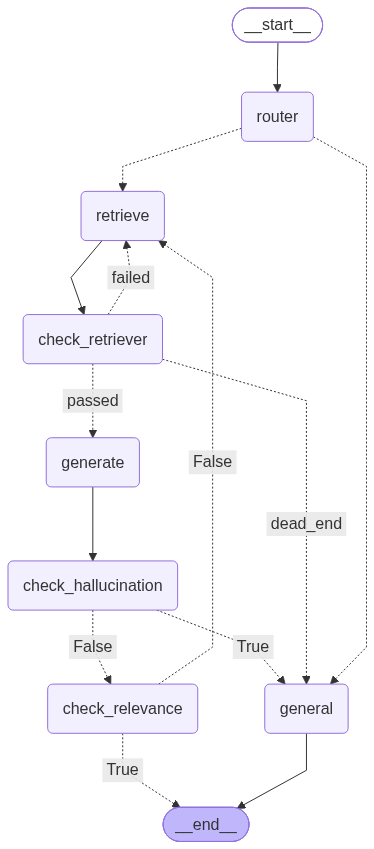

In [39]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [42]:
result = graph.invoke({"question": "What is Millennium and Anthropic building together? Is it a digital risk analyst? if so what is it?"})
result["answer"]

"Yes, Millennium and Anthropic are building a digital risk analyst together. It is an AI teammate designed to work alongside and under the supervision of the firm's risk managers. The digital risk analyst aims to surface new risk insights and form opinions on risk exposure across various asset classes, helping risk managers expedite and enrich their analysis of risk positions."